<Axes: xlabel='Longitude', ylabel='Latitude'>

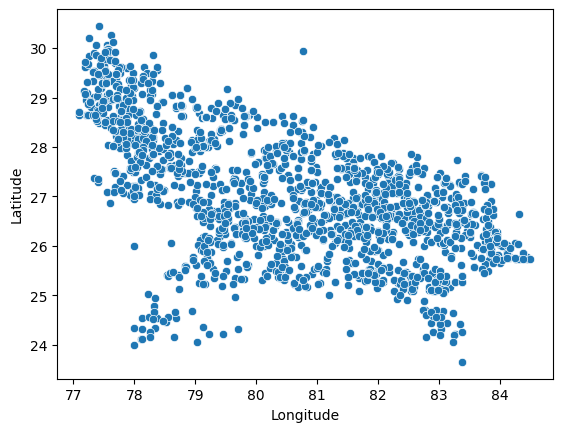

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
df = pd.read_csv('clustering_data.csv', low_memory=False) #using low_memory = False to avoid dtype warning
ts = df[df['StateName'] == 'UTTAR PRADESH'].copy()
#some latitude/longitudes are in string+integer types
ts['Latitude']  = pd.to_numeric(ts['Latitude'],  errors='coerce')
ts['Longitude'] = pd.to_numeric(ts['Longitude'], errors='coerce')
#dropping NaNs
ts = ts.dropna(subset=['Latitude', 'Longitude'])
#cleaning data so that it is within bounds
ts = ts[(ts['Latitude']  >= 23.5) & (ts['Latitude']  <= 30.5) & (ts['Longitude'] >= 77.0) & (ts['Longitude'] <= 84.5)]

coords = ts[['Latitude', 'Longitude']].values

#Visualising pincodes 
ts_sample = ts.sample(2000, random_state=42) #there were too many data points before, taking a sample of 2000
sns.scatterplot(data=ts_sample, x='Longitude', y='Latitude')

Converged at iteration 11
Converged at iteration 13
Converged at iteration 14
Converged at iteration 15
Converged at iteration 24
Converged at iteration 24
Converged at iteration 41
Converged at iteration 17


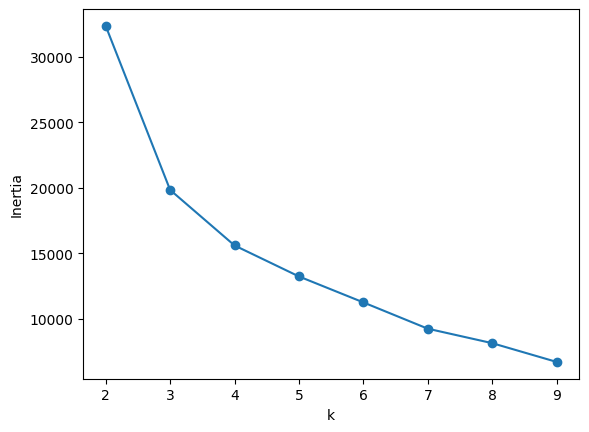

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#initial ks
def kscratch(X, k, max_iter=250, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), k, replace=False)
    centroids = X[idx].astype(float)

    for iteration in range(max_iter):
        #calculate distance from every point to every centroid
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        #Assign each point to nearest centroid
        labels = np.argmin(dists, axis=1)

        #update
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if (labels == j).sum() > 0 else centroids[j]
            for j in range(k)
        ])

        #if centroids barely moved then we can stop
        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"Converged at iteration {iteration+1}")
            break

        centroids = new_centroids

    return labels, centroids


#implementing elbow method
inertias = []

for k in range(2, 10):
    labels, centroids = kscratch(coords, k)
    #Inertia = sum of squared distances from each point to its centroid
    inertia = sum(np.linalg.norm(coords[labels == j] - centroids[j]) ** 2 for j in range(k))
    inertias.append(inertia)

plt.plot(range(2, 10), inertias, 'o-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

#the curve clearly bends at k=3


Converged at iteration 13


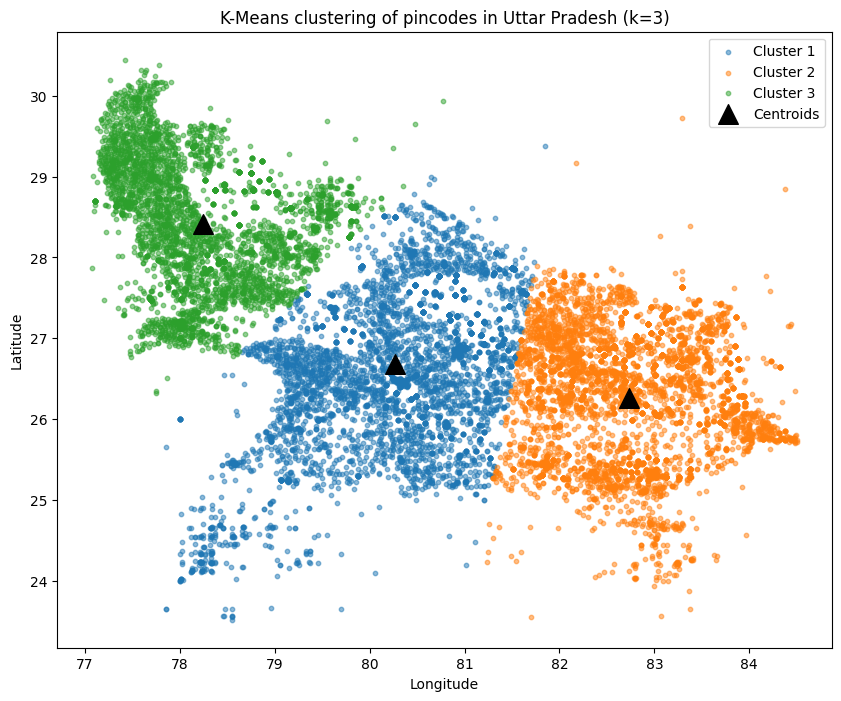

In [ ]:

K = 3
labels, centroids = kscratch(coords, k=K)
#adding cluster labels
ts['Cluster'] = labels

#visualising clusters
plt.figure(figsize=(10, 8))
for c in range(K):
    mask = labels == c
    plt.scatter(coords[mask, 1], coords[mask, 0], s=10, alpha=0.5, label=f'Cluster {c+1}')

plt.scatter(centroids[:, 1], centroids[:, 0], s=200, color='black', marker='^', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means clustering of pincodes in Uttar Pradesh (k={K})')
plt.legend()
plt.show()

Converged at iteration 14


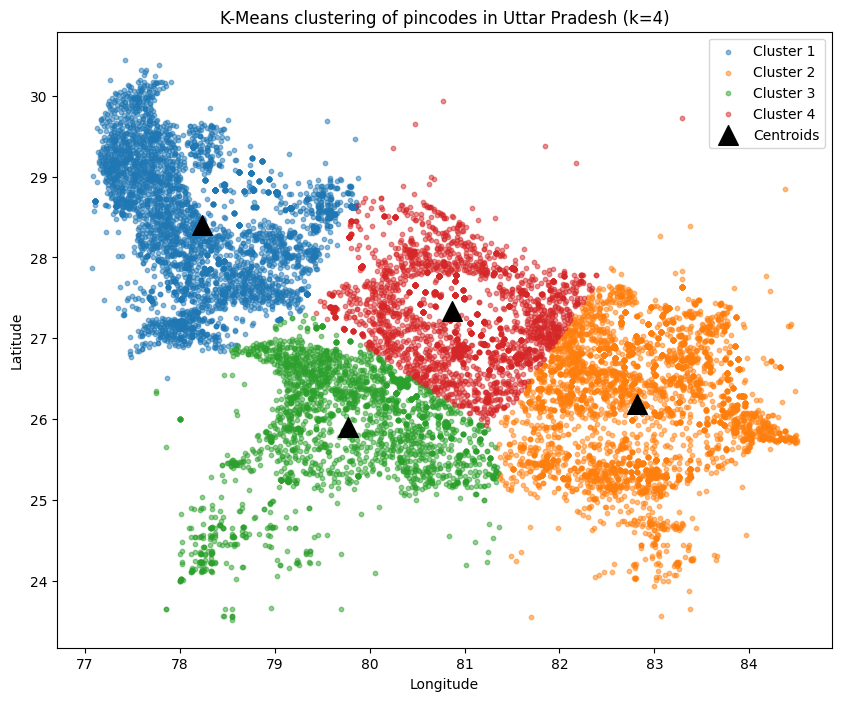

In [ ]:
#if we use k = 4

K = 4
labels, centroids = kscratch(coords, k=K)
#adding cluster labels
ts['Cluster'] = labels

#visualising clusters
plt.figure(figsize=(10, 8))
for c in range(K):
    mask = labels == c
    plt.scatter(coords[mask, 1], coords[mask, 0], s=10, alpha=0.5, label=f'Cluster {c+1}')

plt.scatter(centroids[:, 1], centroids[:, 0], s=200, color='black', marker='^', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means clustering of pincodes in Uttar Pradesh (k={K})')
plt.legend()
plt.show()

In [ ]:
#as we can see from the clusters made, there is a pretty clear density variation. This variation signifies that perhaps the clusters/geographical areas with more pincodes
#have more post offices and therefore have better postal infrastructure. The area towards the west is clearly very dense due to the influence of the NCR/Delhi region. 
#clusters containing Kanpur/Lucknow are also very tight to due urbanisation.
#towards the borders, the situation is very sparse due to rural areas in nepal/bihar regions.

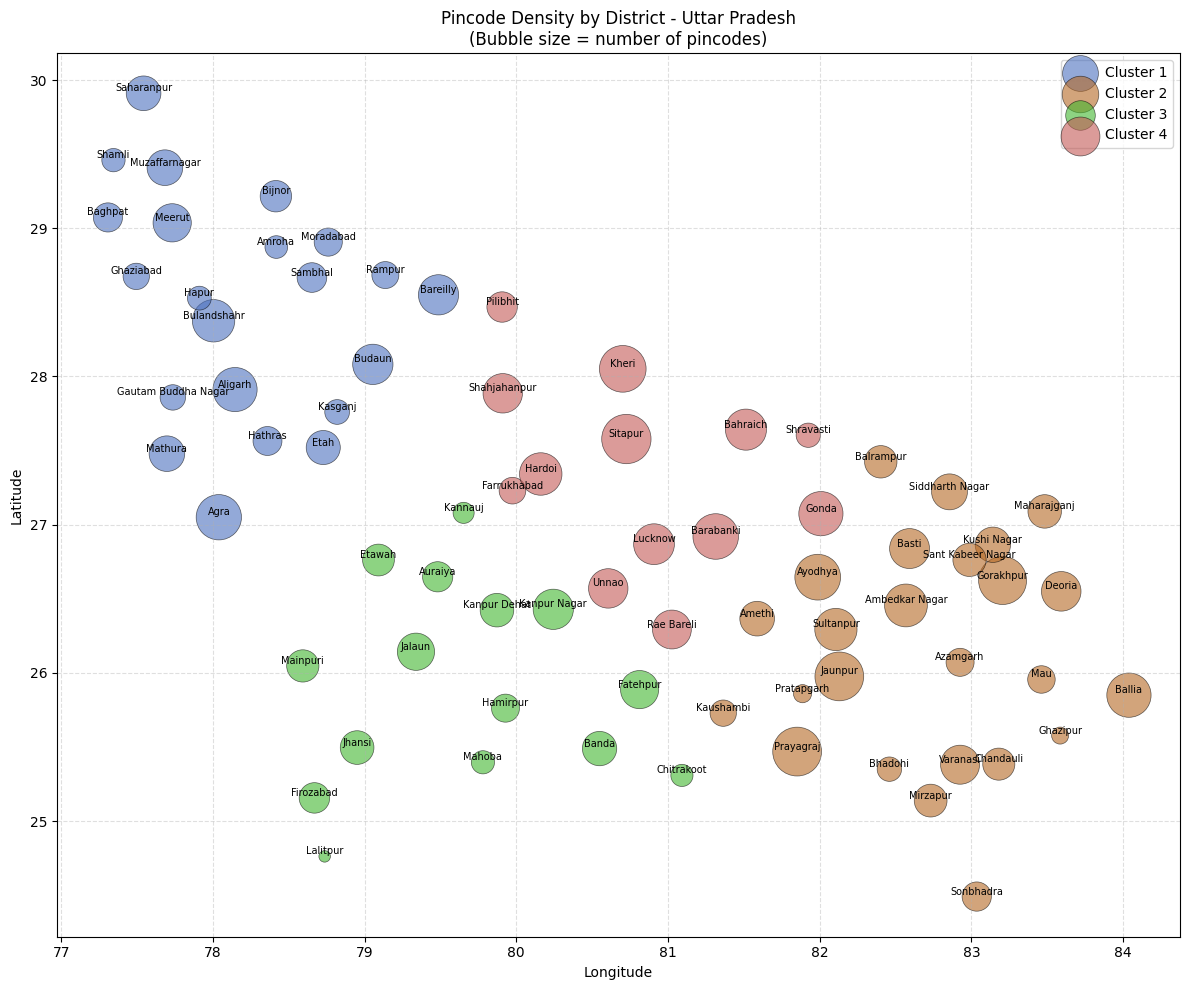

In [ ]:
#another visualisation [by district] using a bubble map

# District-level summary
district_summary = ts.groupby('District').agg(
    lat=('Latitude', 'mean'),
    lon=('Longitude', 'mean'),
    count=('Pincode', 'count'),
    cluster=('Cluster', lambda x: x.mode()[0])
).reset_index()

COLORS = ["#4B70BE", "#B56824", "#41B72F", "#C35956"]  #the colors respond to those of the clusters

fig, ax = plt.subplots(figsize=(12, 10))

for c in range(K):
    subset = district_summary[district_summary['cluster'] == c]
    ax.scatter(
        subset['lon'], subset['lat'],
        s=subset['count'] * 3,      #bubble size corresponds to the pincode count
        color=COLORS[c],
        alpha=0.6,
        edgecolors='black',
        linewidths=0.5,
        label=f'Cluster {c+1}'
    )

#Labeling each district
for _, row in district_summary.iterrows():
    ax.annotate(
        row['District'].title(),
        xy=(row['lon'], row['lat']),
        fontsize=7,
        ha='center',
        va='bottom'
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Pincode Density by District - Uttar Pradesh\n(Bubble size = number of pincodes)')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()